In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use('dark_background')

In [31]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


## LOAD DATASET

In [32]:
df = pd.read_csv("../data/housing.csv")

## BASIC INSPECTION

In [33]:
display(df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [34]:
df.shape

(20640, 10)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [36]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## MISSING VALUE ANALYSIS

In [37]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

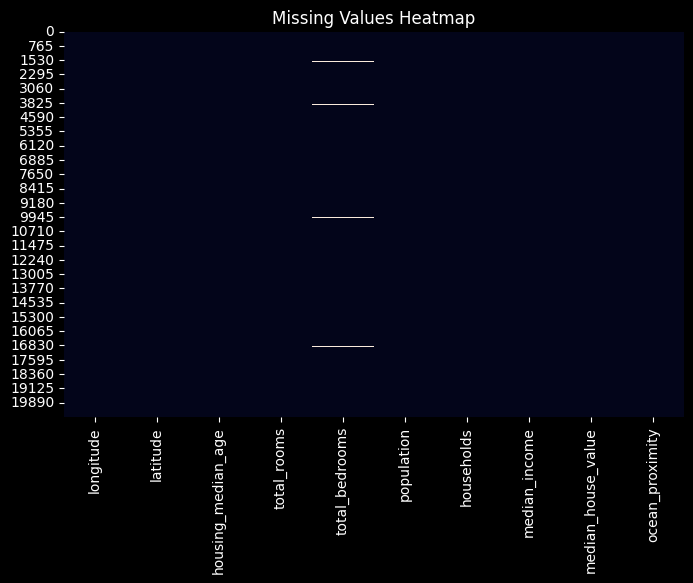

In [38]:
plt.figure(figsize=(8,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

## TARGET VARIABLE ANALYSIS

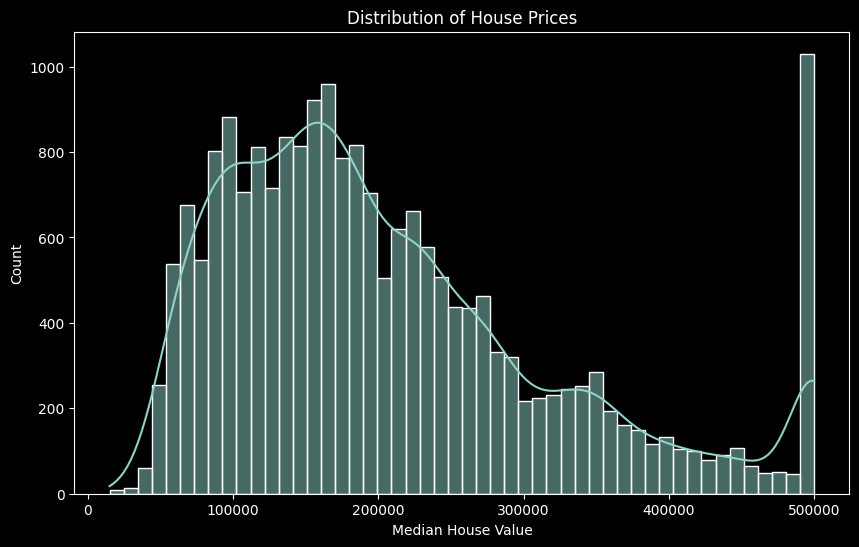

In [39]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["median_house_value"],
    bins=50,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Median House Value")

plt.savefig("../outputs/DistributionOfHousePrices.png")

plt.show()

## NUMERICAL FEATURE ANALYSIS

In [40]:
num_cols = df.select_dtypes(
    include=np.number
).columns

num_cols

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

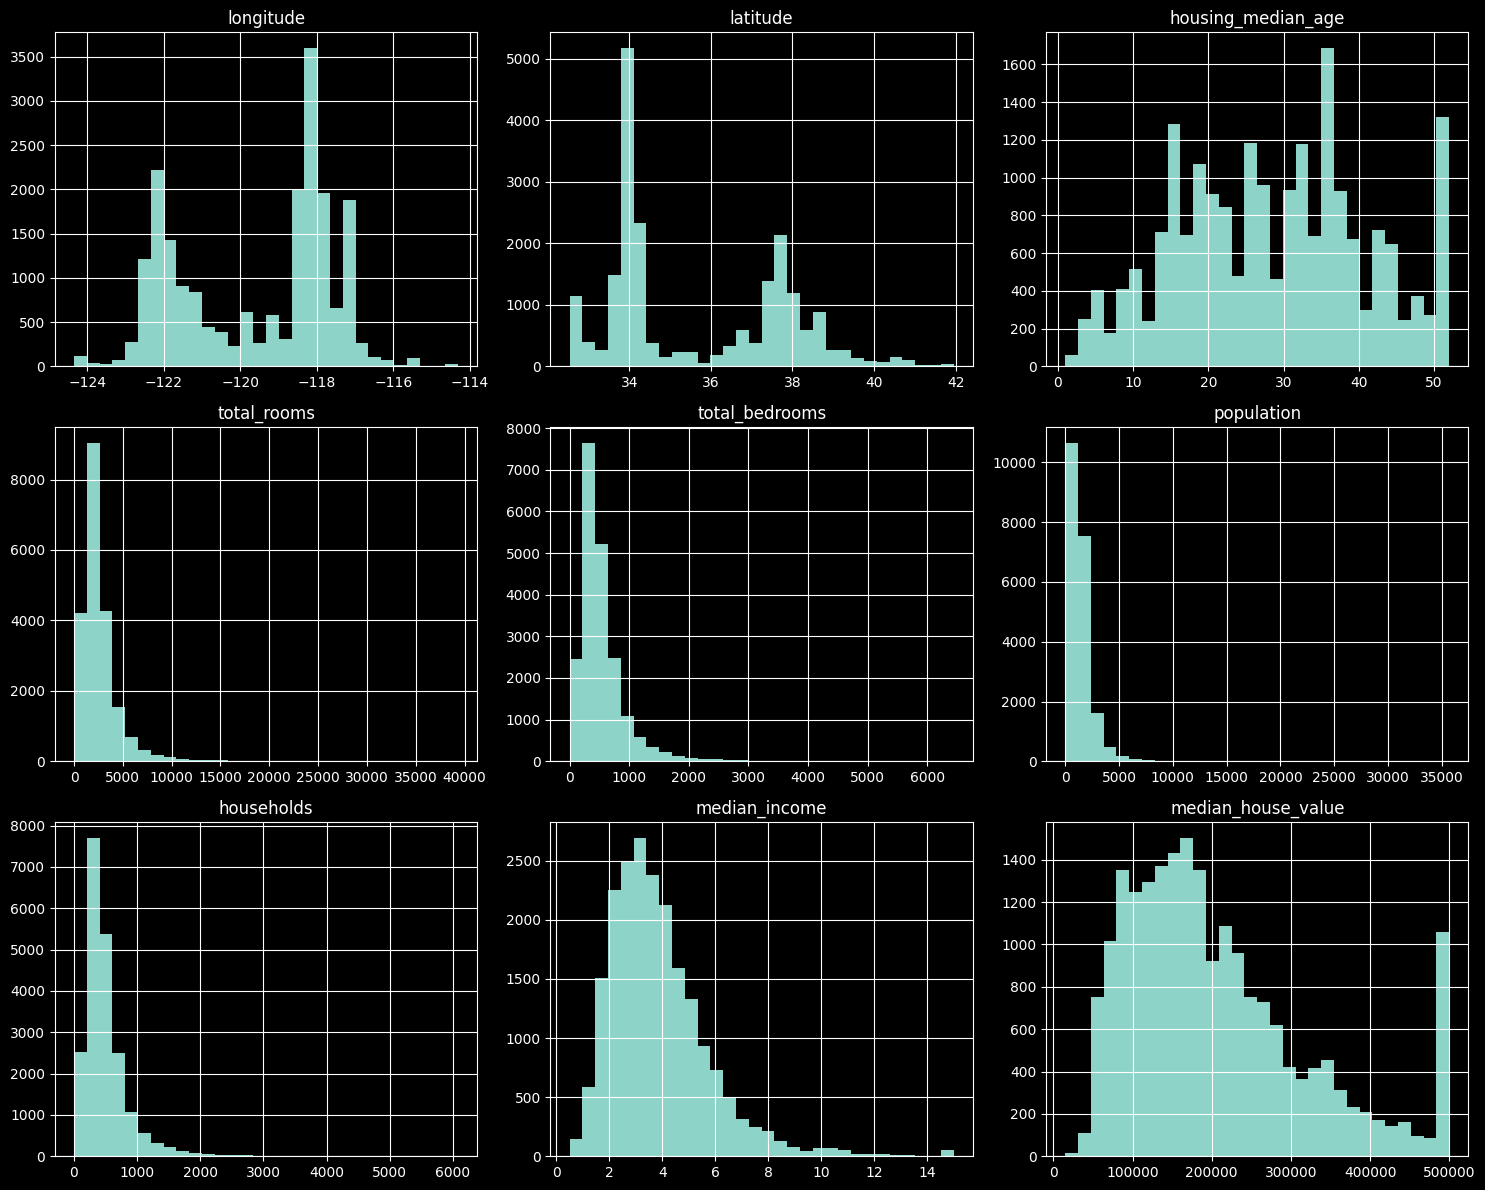

In [41]:
df[num_cols].hist(
    figsize=(15,12),
    bins=30
)

plt.tight_layout()


plt.savefig("../outputs/histplot.png")
plt.show()


## CATEGORICAL FEATURE ANALYSIS

In [42]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

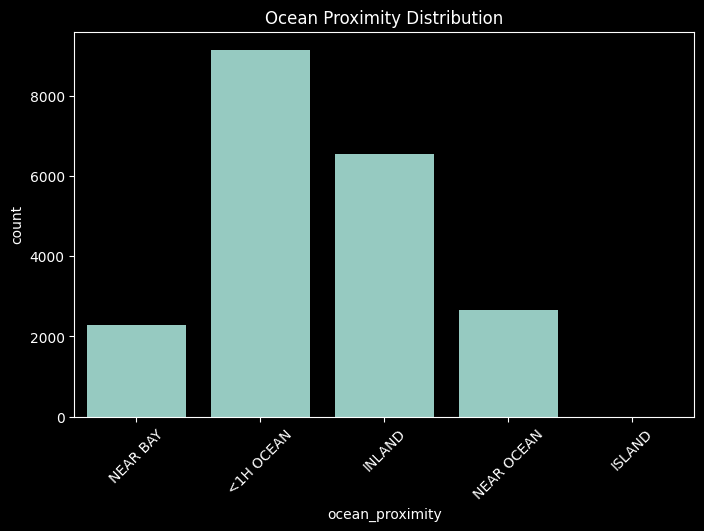

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="ocean_proximity",
    data=df
)

plt.xticks(rotation=45)

plt.title("Ocean Proximity Distribution")

plt.savefig("../outputs/OceanProximityDistribution.png")
plt.show()

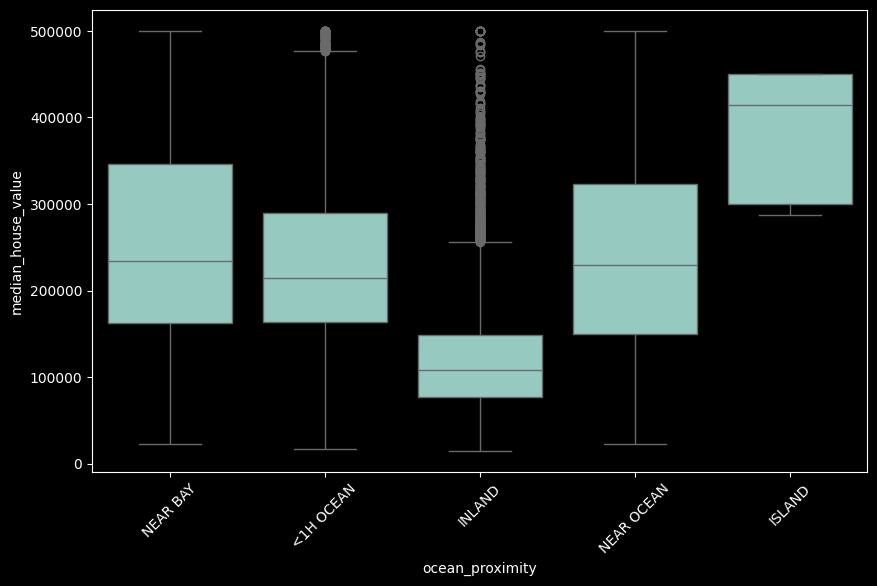

In [44]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="ocean_proximity",
    y="median_house_value",
    data=df
)

plt.xticks(rotation=45)

plt.savefig("../outputs/OceanProximityBoxplot.png")
plt.show()

Houses near ocean:

generally more expensive

This is a strong predictive signal.

## CORRELATION ANALYSIS

In [45]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [46]:
corr_matrix["median_house_value"]\
.sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

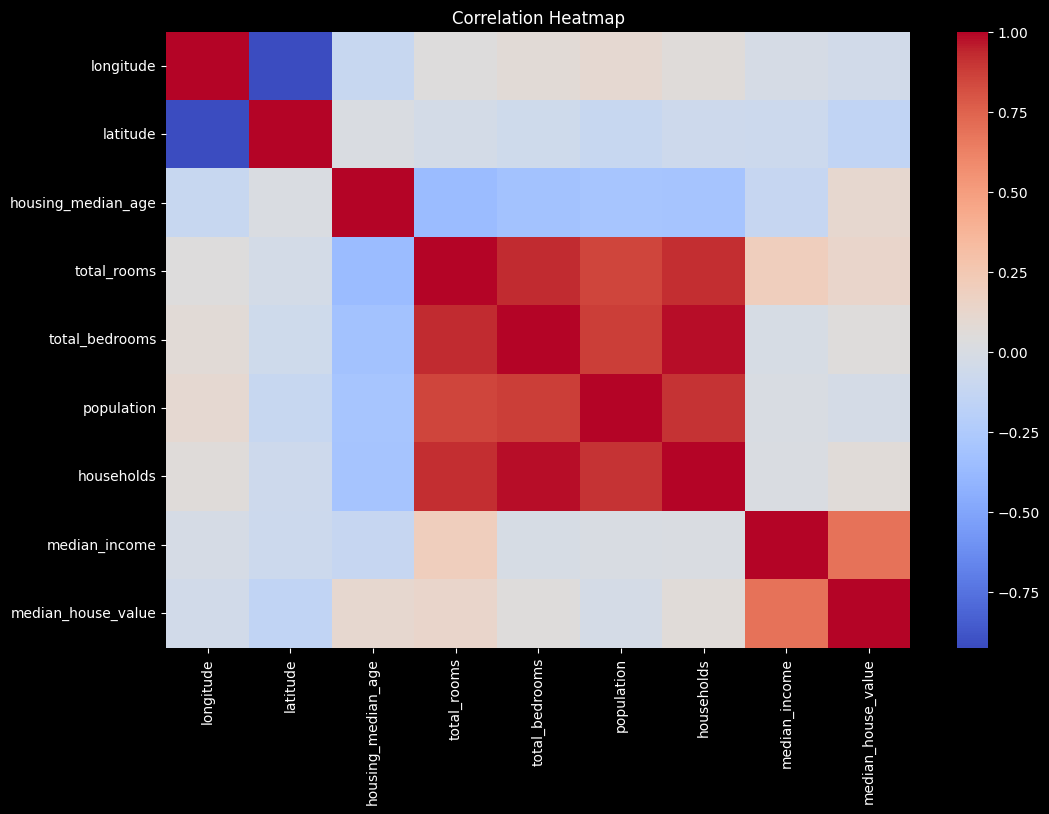

In [47]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.savefig("../outputs/CorrelationHeatmap.png")
plt.show()

## SCATTERPLOT ANALYSIS

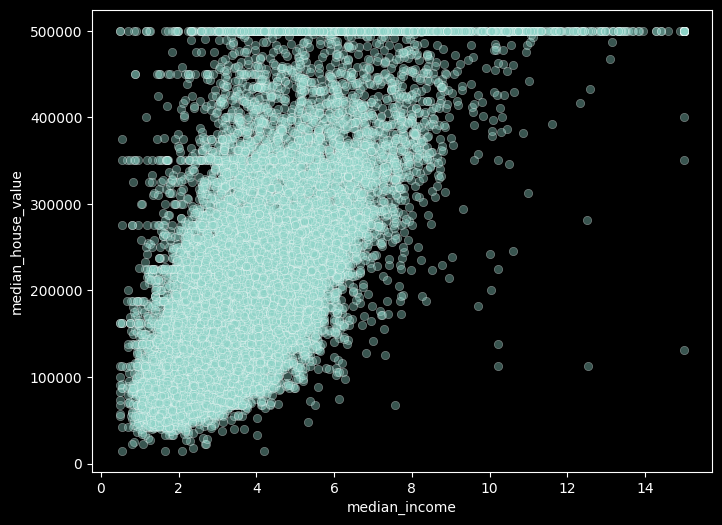

In [48]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="median_income",
    y="median_house_value",
    data=df,
    alpha=0.4
)

plt.savefig("../outputs/IncomeVsHouseValue.png")
plt.show()

## GEOSPATIAL ANALYSIS

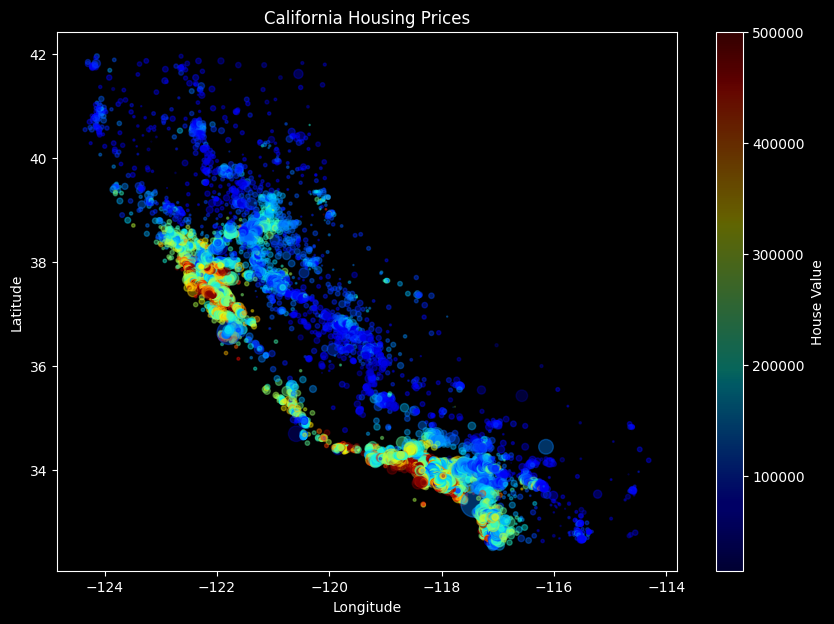

In [49]:
plt.figure(figsize=(10,7))

plt.scatter(
    df["longitude"],
    df["latitude"],
    alpha=0.4,
    s=df["population"]/100,
    c=df["median_house_value"],
    cmap="jet"
)

plt.colorbar(label="House Value")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("California Housing Prices")

plt.savefig("../outputs/CaliforniaHousingPrices.png")
plt.show()

## OUTLIER ANALYSIS

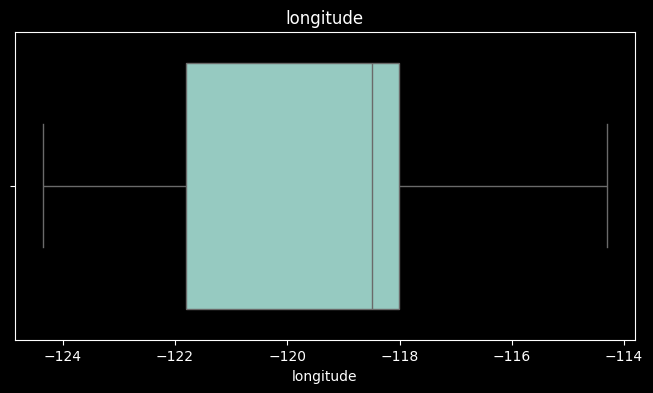

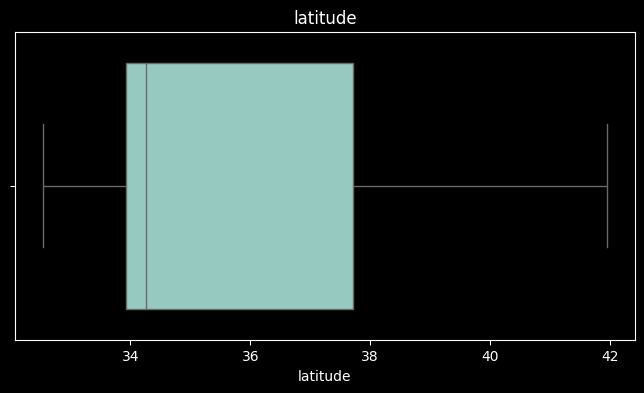

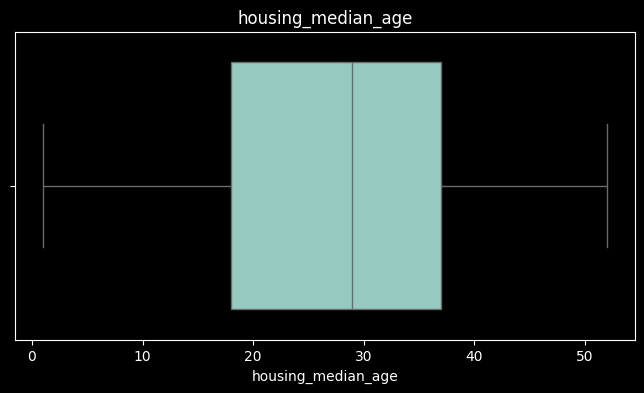

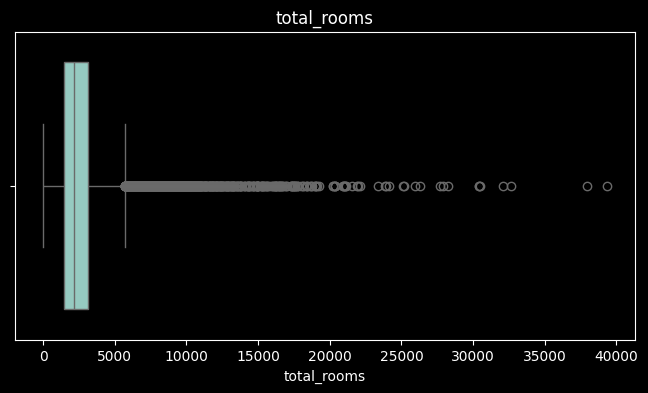

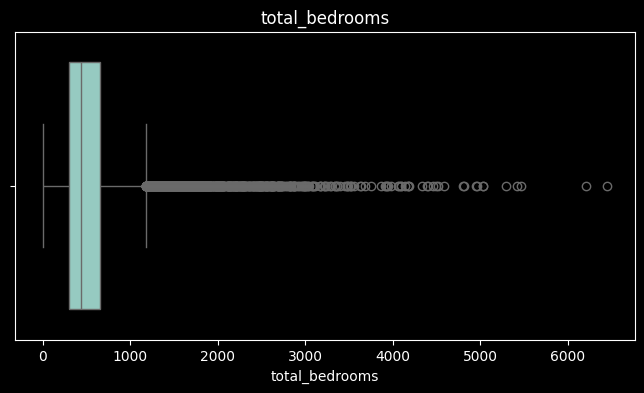

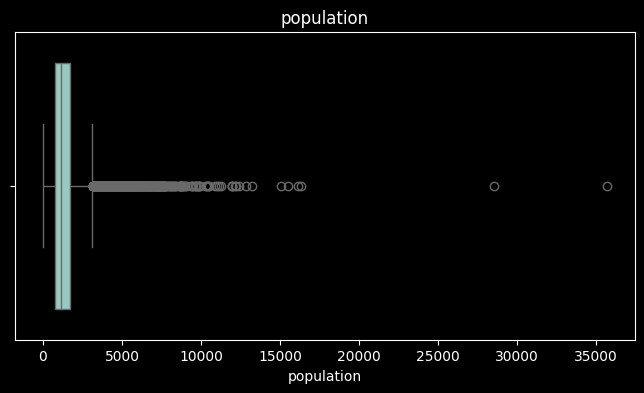

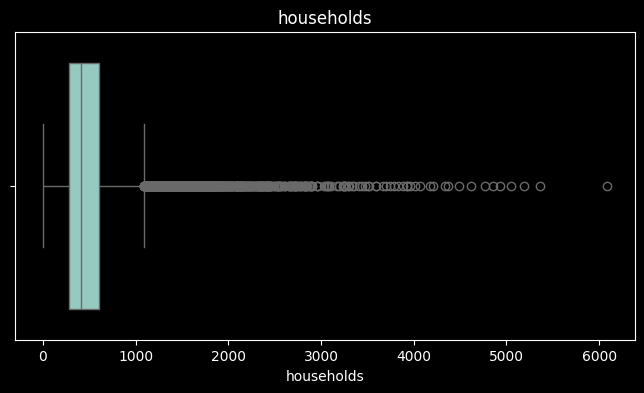

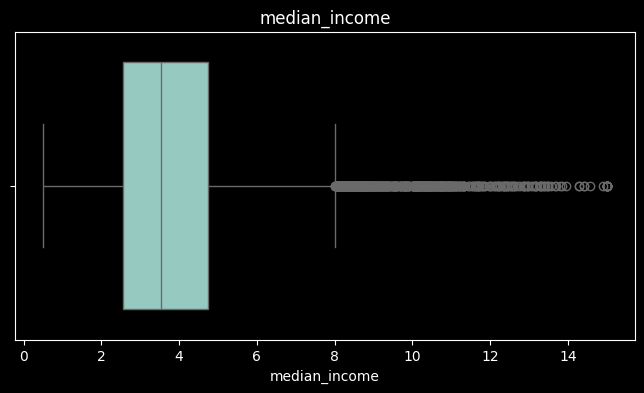

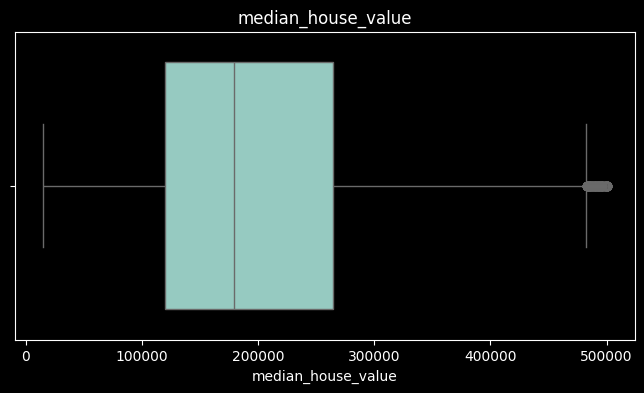

In [50]:
for col in num_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(x=df[col])
    
    plt.title(col)
    
    plt.savefig(f"../outputs/Boxplot_{col}.png")
    plt.show()
   

## FEATURE ENGINEERING INSIGHTS

In [51]:
df["rooms_per_household"] = (
    df["total_rooms"] /
    df["households"]
)

In [52]:
df["bedrooms_per_room"] = (
    df["total_bedrooms"] /
    df["total_rooms"]
)

In [53]:
df["population_per_household"] = (
    df["population"] /
    df["households"]
)

## CHECK NEW CORRELATIONS

In [54]:
new_corr = df.corr(numeric_only=True)

new_corr["median_house_value"]\
.sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049686
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64

## DISTRIBUTION SKEWNESS

In [55]:
df[num_cols].skew()\
.sort_values(ascending=False)

population            4.935858
total_rooms           4.147343
total_bedrooms        3.459546
households            3.410438
median_income         1.646657
median_house_value    0.977763
latitude              0.465953
housing_median_age    0.060331
longitude            -0.297801
dtype: float64

## PAIRPLOT

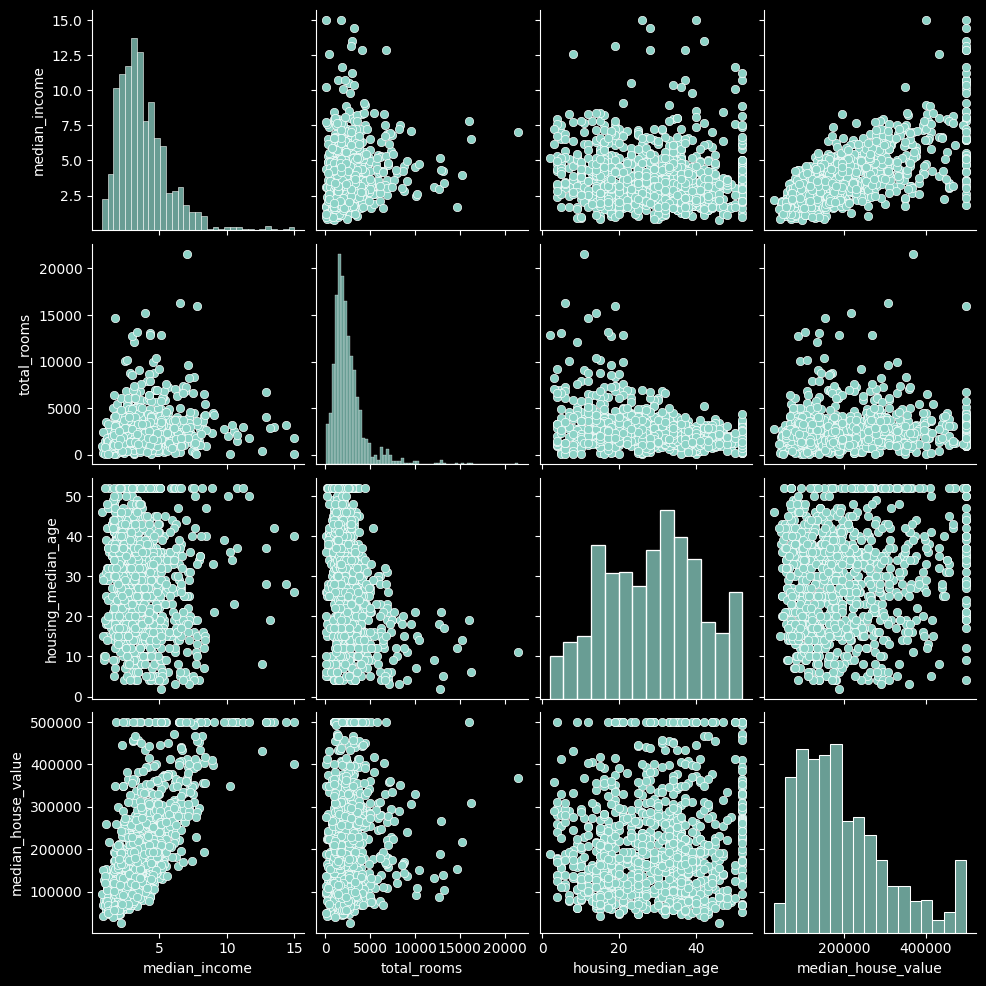

In [56]:
sample_df = df.sample(1000)

sns.pairplot(
    sample_df[
        [
            "median_income",
            "total_rooms",
            "housing_median_age",
            "median_house_value"
        ]
    ]
)

plt.savefig("../outputs/Pairplot.png")
plt.show()

Key Findings:

1. median_income has strongest positive correlation with house prices.

2. Ocean proximity significantly impacts property value.

3. House prices are capped around $500,000.

4. Several numerical columns contain strong outliers.

5. Many features are right-skewed.

6. Geographical location strongly influences pricing.

7. Engineered ratio-based features may improve model performance.